# pymodal — Dimensional collections, references, and typed indicators

A didactic tour of the post-refactor architecture. **No model training** —
that lives in the companion `demo.ipynb`. This notebook walks through every
user-facing feature with a plot for each:

1. The four dimensional parents (0-D / 1-D / 2-D / 3-D).
2. Building a 1-D `frf` collection — single-array vs multi-array constructors.
3. Inside the HDF5 file: items, axes, channel metadata.
4. Domain-edition methods (`change_freq_span`, `change_freq_resolution`).
5. Reference linking (embed-by-copy) — the consumer is self-contained.
6. Source-survival demo — delete the source, references still resolve.
7. `timeseries.to_FRF` auto-registers `{"input", "output"}` references.
8. Typed indicators — 2-D matrices, 1-D vectors, 0-D scalars.
9. Provenance round-trip — recover sources from any indicator.
10. PyTorch handoff with variable-rank items.

In [1]:
# ── Install / verify pymodal at the head of master ──
import sys, subprocess, inspect

def _has_post_refactor_api():
    try:
        import pymodal
        # Feature check: post-refactor frf.__init__ accepts a `path` kwarg.
        return "path" in inspect.signature(pymodal.frf.__init__).parameters
    except Exception:
        return False


if not _has_post_refactor_api():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pyFRF>=0.40", "pint>=0.20.1", "audiomentations>=0.31.0",
                           "h5py", "numpy", "matplotlib"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--no-deps", "--force-reinstall", "--no-cache-dir",
                           "git+https://github.com/grcarmenaty/pymodal.git@master"])
    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
else:
    import pymodal
    print("pymodal", pymodal.__version__, "ready (post-refactor API detected).")

pymodal 0.2.0 ready (post-refactor API detected).


In [2]:
import warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import pymodal
print(f"pymodal version: {pymodal.__version__}")

pymodal version: 0.2.0


## 1 · The dimensional hierarchy

Every collection subclasses one of four dimensional parents. The number of
**functional domain axes** (`_n_domain_axes`) is fixed at the class level
and determines item rank; channel/DOF metadata `(n_outputs, n_inputs)` is
always the trailing two axes.

Dimensional parents:
  _collection_0d      _n_domain_axes=0  → item rank = 2
  _collection_1d      _n_domain_axes=1  → item rank = 3
  _collection_2d      _n_domain_axes=2  → item rank = 4
  _collection_3d      _n_domain_axes=3  → item rank = 5


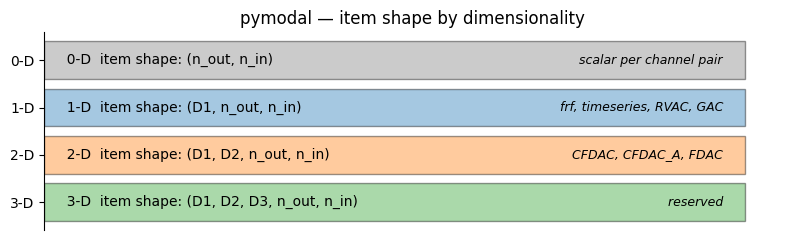

In [3]:
print("Dimensional parents:")
for cls in (pymodal._collection_0d, pymodal._collection_1d,
            pymodal._collection_2d, pymodal._collection_3d):
    print(f"  {cls.__name__:18s}  _n_domain_axes={cls._n_domain_axes}  "
          f"→ item rank = {cls._n_domain_axes + 2}")

# Visual schematic of item ranks
fig, ax = plt.subplots(figsize=(8, 2.5))
levels = [
    ("0-D", "(n_out, n_in)",                 "scalar per channel pair",       "tab:gray"),
    ("1-D", "(D1, n_out, n_in)",             "frf, timeseries, RVAC, GAC",    "tab:blue"),
    ("2-D", "(D1, D2, n_out, n_in)",         "CFDAC, CFDAC_A, FDAC",          "tab:orange"),
    ("3-D", "(D1, D2, D3, n_out, n_in)",     "reserved",                      "tab:green"),
]
for i, (name, shape, desc, color) in enumerate(levels):
    ax.barh(i, 1.0, color=color, alpha=0.4, edgecolor="black")
    ax.text(0.02, i, f"  {name}  item shape: {shape}", va="center", fontsize=10)
    ax.text(0.98, i, f"{desc}  ", va="center", ha="right", fontsize=9, style="italic")
ax.set_yticks(range(len(levels)))
ax.set_yticklabels([l[0] for l in levels])
ax.set_xticks([]); ax.invert_yaxis(); ax.set_title("pymodal — item shape by dimensionality")
for spine in ("top", "right", "bottom"):
    ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

## 2 · Building a 1-D `frf` collection (with structured FRFs)

We synthesise SDOF accelerances for an N-DOF model where every DOF has its
own natural frequency. This gives a structurally meaningful FRF (one resonance
per DOF) so all the downstream indicators have visible structure.

len(single)              : 1
single.measurements[0]   : (51, 8, 1)
single.channel_shape()   : (8, 1)
single.domain_shape()    : (51,)


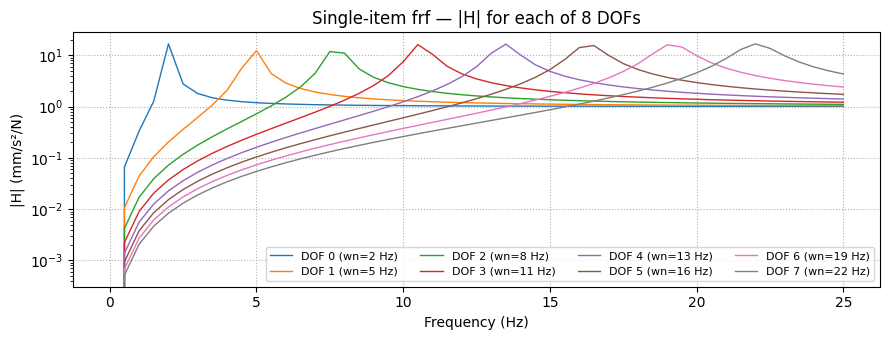

In [4]:
WORK = Path("./_pymodal_arch_demo"); WORK.mkdir(exist_ok=True)
RNG = np.random.default_rng(0)

# Frequency grid 0–25 Hz at Δf = 0.5 Hz
N_FREQ = 51
freqs  = np.linspace(0, 25, N_FREQ)
omega  = 2 * np.pi * freqs

N_DOF = 8
WN_HZ = np.linspace(2.0, 22.0, N_DOF)   # one resonance per DOF
ZETA  = 0.03


def sdof_accelerance(omega, wn_hz, zeta=ZETA, m=1.0):
    """SDOF accelerance: ẍ/F = −ω² / (k − mω² + jcω)."""
    wn = 2 * np.pi * wn_hz
    k  = m * wn**2
    c  = 2 * zeta * np.sqrt(k * m)
    return -omega**2 / (k - m * omega**2 + 1j * c * omega)


def build_frf(wn_array, perturb=None):
    """Build a multi-DOF FRF, one row per natural frequency.
    Returns an array of shape (N_FREQ, N_DOF, 1)."""
    H = np.zeros((N_FREQ, N_DOF, 1), dtype=np.complex64)
    for i, wn in enumerate(wn_array):
        H[:, i, 0] = sdof_accelerance(omega, wn).astype(np.complex64)
    if perturb is not None:
        H *= perturb[None, :, None]
    return H


# Three structural states — variations on the same N-DOF system
H_healthy = build_frf(WN_HZ)
H_cracked = build_frf(WN_HZ, perturb=np.where(np.arange(N_DOF) == 4, 0.85, 1.0))   # 15 % loss at DOF 4
H_loose   = build_frf(WN_HZ * np.where(np.arange(N_DOF) == 6, 0.92, 1.0))           # DOF 6 wn shifted

# Single-array constructor — 1-item collection
single = pymodal.frf(
    measurements=H_healthy,
    freq_resolution=0.5, freq_units="hertz",
    method="SIMO", name="solo",
    path=WORK / "single.h5",
)
print(f"len(single)              : {len(single)}")
print(f"single.measurements[0]   : {single.measurements[0].shape}")
print(f"single.channel_shape()   : {single.channel_shape()}")
print(f"single.domain_shape()    : {single.domain_shape()}")

# Plot — magnitude of every DOF row
fig, ax = plt.subplots(figsize=(9, 3.5))
H = single.measurements[0][()]
for i in range(N_DOF):
    ax.semilogy(single.freq_array, np.abs(H[:, i, 0]),
                lw=1.0, label=f"DOF {i} (wn={WN_HZ[i]:.0f} Hz)")
ax.set(title="Single-item frf — |H| for each of 8 DOFs",
       xlabel="Frequency (Hz)", ylabel="|H| (mm/s²/N)")
ax.legend(ncol=4, fontsize=8); ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()

len(many)                : 3
many.name                : ['healthy', 'cracked', 'loose']
many.labels              : [np.int64(0), np.int64(1), np.int64(2)]


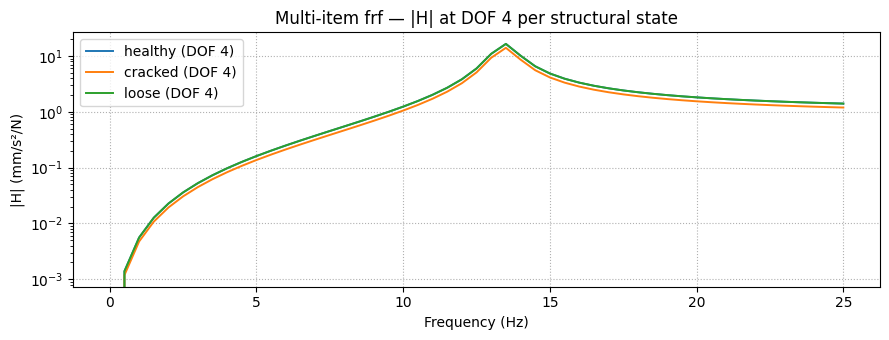

In [5]:
# Multi-array constructor → multi-item collection (one item per structural state)
many = pymodal.frf(
    measurements=[H_healthy, H_cracked, H_loose],
    freq_resolution=0.5, freq_units="hertz",
    method="SIMO",
    names=["healthy", "cracked", "loose"],
    labels=[0, 1, 2],
    path=WORK / "many.h5",
)
print(f"len(many)                : {len(many)}")
print(f"many.name                : {many.name}")
print(f"many.labels              : {[l[()] for l in many.labels]}")

# Overlay one DOF per state to see the perturbations
fig, ax = plt.subplots(figsize=(9, 3.5))
COLORS = {"healthy": "tab:blue", "cracked": "tab:orange", "loose": "tab:green"}
for i, n in enumerate(many.name):
    H = many.measurements[i][()]
    ax.semilogy(many.freq_array, np.abs(H[:, 4, 0]),
                color=COLORS[n], lw=1.4, label=f"{n} (DOF 4)")
ax.set(title="Multi-item frf — |H| at DOF 4 per structural state",
       xlabel="Frequency (Hz)", ylabel="|H| (mm/s²/N)")
ax.legend(); ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()

## 3 · Inside the HDF5 file

Every collection writes a single HDF5 file with a uniform layout. A generic
reader (and `HDF5Dataset`) can therefore handle 0-D / 1-D / 2-D collections
without special-casing.

/measurements/.attrs
  coordinates          [[0. 0. 0.]
 [1. 0. 0.]
 [2. 0. 0.]
 [3. 0. 0.]
 [4. 0. 0.]
 [5. 0. 0.]
 [6. 0. 0.]
 [7. 0. 0.]]
  dof                  8
  measurements_units   millimeter / second ** 2 / newton
  method               SIMO
  n_domain_axes        1
  n_inputs             1
  n_outputs            8
  orientations         [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
  space_units          millimeter

/measurements/_axes/  (one dataset per domain axis)
  axis_0/data shape=(51,)  units='hertz'

/measurements/{name}/  (one group per item)
  healthy/data shape=(51, 8, 1)
  cracked/data shape=(51, 8, 1)
  loose/data shape=(51, 8, 1)


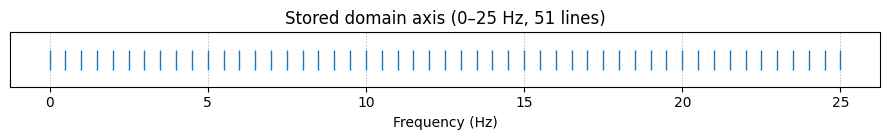

In [6]:
with h5py.File(many.path, "r") as f:
    print("/measurements/.attrs")
    for k, v in f["measurements"].attrs.items():
        print(f"  {k:20s} {v}")
    print("\n/measurements/_axes/  (one dataset per domain axis)")
    for name, ds in f["measurements/_axes"].items():
        print(f"  {name}/data shape={ds.shape}  units={ds.attrs['units']!r}")
    print("\n/measurements/{name}/  (one group per item)")
    for name in many.name:
        print(f"  {name}/data shape={f[f'measurements/{name}/data'].shape}")

# Visualise the on-disk frequency axis — same data the dataset reads at training time
fig, ax = plt.subplots(figsize=(9, 1.5))
with h5py.File(many.path, "r") as f:
    axis = f["measurements/_axes/axis_0"][()]
ax.plot(axis, np.zeros_like(axis), "|", markersize=14)
ax.set(title="Stored domain axis (0–25 Hz, 51 lines)", xlabel="Frequency (Hz)")
ax.set_yticks([]); ax.grid(True, linestyle=":", axis="x")
plt.tight_layout(); plt.show()

## 4 · Domain edition — `change_freq_span` and `change_freq_resolution`

Both methods mutate the HDF5 file in place and return `self` for chaining.

Original  : 51 lines, Δf = 0.5 Hz
Trimmed   : 25 lines, span 0–12.0 Hz
Coarsened : 13 lines, Δf ≈ 1.00 Hz


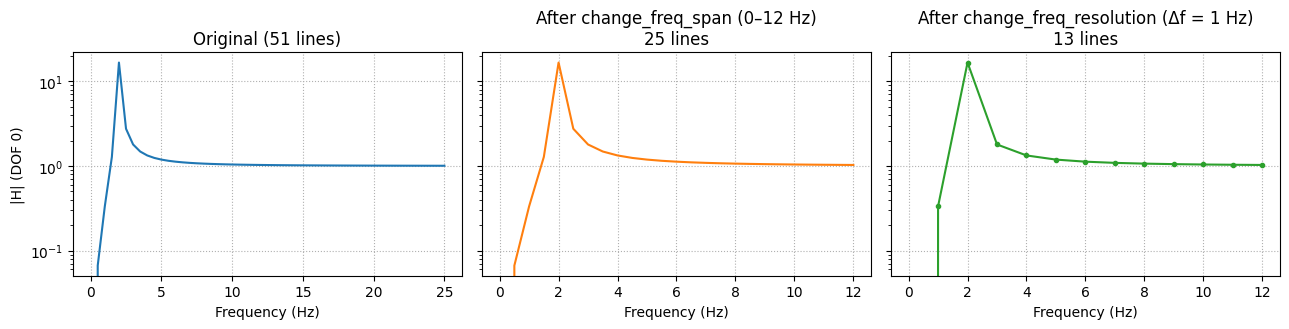

In [7]:
edit = pymodal.frf(
    measurements=H_healthy, freq_resolution=0.5,
    method="SIMO", name="edit", path=WORK / "edit.h5",
)
n_orig = edit.measurements[0].shape[0]
freq_orig = edit.freq_array.copy()

edit.change_freq_span(new_min_freq=0.0, new_max_freq=12.0)
freq_trim = edit.freq_array.copy()
H_trim    = edit.measurements[0][()].copy()

edit.change_freq_resolution(1.0)
freq_coarse = edit.freq_array.copy()
H_coarse    = edit.measurements[0][()].copy()

print(f"Original  : {n_orig} lines, Δf = 0.5 Hz")
print(f"Trimmed   : {len(freq_trim)} lines, span 0–{freq_trim[-1]} Hz")
print(f"Coarsened : {len(freq_coarse)} lines, Δf ≈ {edit.freq_resolution:.2f} Hz")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
axes[0].semilogy(freq_orig,   np.abs(H_healthy[:, 0, 0]))
axes[0].set(title=f"Original ({n_orig} lines)", xlabel="Frequency (Hz)", ylabel="|H| (DOF 0)")
axes[1].semilogy(freq_trim,   np.abs(H_trim[:, 0, 0]),  color="tab:orange")
axes[1].set(title=f"After change_freq_span (0–12 Hz)\n{len(freq_trim)} lines", xlabel="Frequency (Hz)")
axes[2].semilogy(freq_coarse, np.abs(H_coarse[:, 0, 0]), "o-", color="tab:green", ms=3)
axes[2].set(title=f"After change_freq_resolution (Δf = 1 Hz)\n{len(freq_coarse)} lines",
            xlabel="Frequency (Hz)")
for ax in axes:
    ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()
edit.close()

## 5 · Reference linking — embed by copy

Any collection can register named **reference collections**. Each reference
is *embedded by copy* into the consumer's HDF5 file under
`/references/{role}/`. The consumer is then self-contained — moving,
deleting, or mutating the source does not affect it.

Reference roles on damaged: ['reference']

/references/reference/.attrs
  collection_class   frf
  index_map          [0 1 2]
  mode               embedded
  n_domain_axes      1


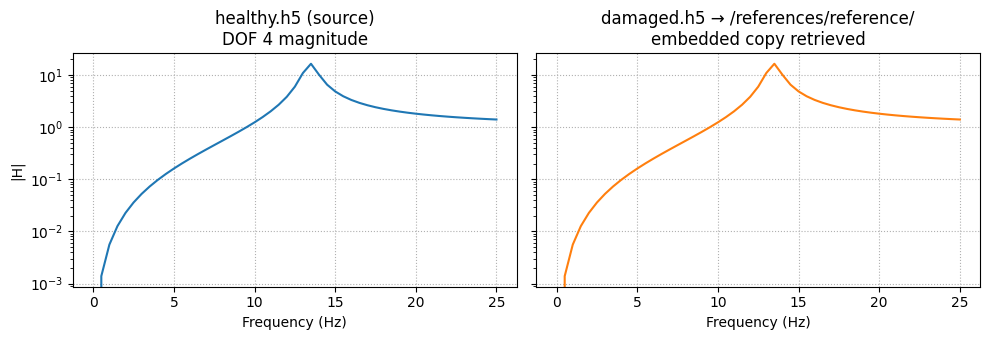

Embedded vs source identical? True


In [8]:
healthy = pymodal.frf(
    measurements=[H_healthy.copy() for _ in range(3)],
    freq_resolution=0.5, method="SIMO",
    names=["h0", "h1", "h2"],
    path=WORK / "healthy.h5",
)
damaged = pymodal.frf(
    measurements=[H_cracked.copy(), H_loose.copy(), H_cracked.copy() * 0.95],
    freq_resolution=0.5, method="SIMO",
    names=["d0", "d1", "d2"], labels=[1, 2, 1],
    references={"reference": healthy},
    reference_index_maps={"reference": [0, 1, 2]},
    path=WORK / "damaged.h5",
)

print("Reference roles on damaged:", damaged.reference_roles())

with h5py.File(damaged.path, "r") as f:
    print("\n/references/reference/.attrs")
    for k, v in f["references/reference"].attrs.items():
        print(f"  {k:18s} {v}")

# Plot original-vs-embedded for a single item to verify identity
ref_back = damaged.get_reference_data("reference", 1)
ref_orig = healthy.measurements[1][()]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].semilogy(damaged.freq_array, np.abs(ref_orig[:, 4, 0]),  "tab:blue",   lw=1.5)
axes[0].set(title="healthy.h5 (source)\nDOF 4 magnitude", xlabel="Frequency (Hz)", ylabel="|H|")
axes[1].semilogy(damaged.freq_array, np.abs(ref_back[:, 4, 0]),  "tab:orange", lw=1.5)
axes[1].set(title="damaged.h5 → /references/reference/\nembedded copy retrieved",
            xlabel="Frequency (Hz)")
for ax in axes:
    ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()
print(f"Embedded vs source identical? {np.allclose(ref_back, ref_orig)}")

## 6 · The reference survives even if the source is deleted

This is what "embed-by-copy" buys you. After deleting `healthy.h5` the
`damaged` collection still resolves its reference for every item — the
bytes live inside `damaged.h5`.

healthy.h5 still exists?  False


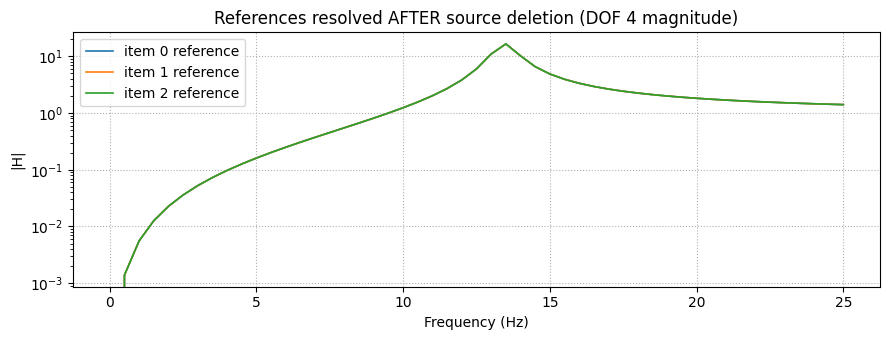

✓ All references still resolvable.


In [9]:
healthy.close(keep=False)             # close handle and DELETE the file
print(f"healthy.h5 still exists?  {(WORK / 'healthy.h5').exists()}")

# damaged still resolves the reference
fig, ax = plt.subplots(figsize=(9, 3.5))
for i in range(len(damaged)):
    ref_arr = damaged.get_reference_data("reference", i)
    ax.semilogy(damaged.freq_array, np.abs(ref_arr[:, 4, 0]),
                lw=1.2, label=f"item {i} reference")
ax.set(title="References resolved AFTER source deletion (DOF 4 magnitude)",
       xlabel="Frequency (Hz)", ylabel="|H|")
ax.legend(); ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()
print("✓ All references still resolvable.")

## 7 · Producer-driven references: `timeseries.to_FRF`

`timeseries.to_FRF(excitation)` automatically registers
`{"input": excitation, "output": self}` on the resulting `frf` so the
provenance of an FRF estimate is captured at the moment of estimation.

to_FRF returned a frf of length 2
reference roles : ['input', 'output']


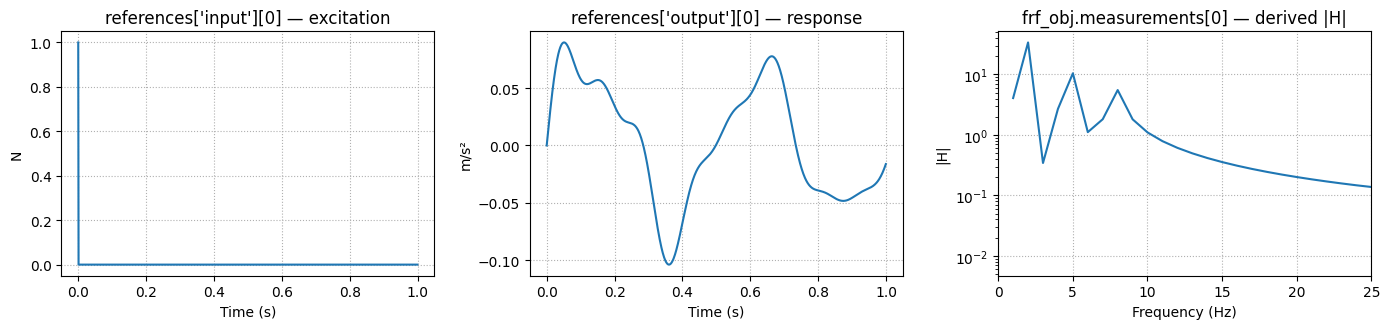

In [10]:
fs = 1024
n  = 1024
t  = np.arange(n) / fs
exc_sig  = np.zeros((n, 1, 1)); exc_sig[0, 0, 0] = 1.0       # impulse
# response: superposition of the same SDOF resonances
resp_sig = np.zeros((n, 1, 1))
for wn in WN_HZ[:3]:                                          # use 3 DOFs for clarity
    om = 2 * np.pi * wn
    om_d = om * np.sqrt(1 - ZETA**2)
    h = np.exp(-ZETA * om * t) * np.sin(om_d * t) / om_d
    resp_sig[:, 0, 0] += h

resp = pymodal.timeseries(
    measurements=[resp_sig.astype(float), resp_sig.astype(float)],
    time_step=1.0 / fs, method="SIMO",
    names=["r0", "r1"], labels=[0, 1],
    path=WORK / "resp.h5",
)
exc = pymodal.timeseries(
    measurements=[exc_sig, exc_sig],
    time_step=1.0 / fs, method="excitation",
    names=["e0", "e1"], path=WORK / "exc.h5",
)

frf_obj = resp.to_FRF(exc, FRF_type="H1", path=WORK / "frf_from_ts.h5")
print(f"to_FRF returned a {type(frf_obj).__name__} of length {len(frf_obj)}")
print(f"reference roles : {frf_obj.reference_roles()}")

# Show all three: input, output, derived FRF — references retrieved from the FRF itself
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
in_arr  = frf_obj.get_reference_data("input",  0)[:, 0, 0]
out_arr = frf_obj.get_reference_data("output", 0)[:, 0, 0]
H_est   = frf_obj.measurements[0][()][:, 0, 0]
axes[0].plot(t, in_arr);                              axes[0].set(title="references['input'][0] — excitation",
                                                                  xlabel="Time (s)", ylabel="N")
axes[1].plot(t, out_arr);                             axes[1].set(title="references['output'][0] — response",
                                                                  xlabel="Time (s)", ylabel="m/s²")
axes[2].semilogy(frf_obj.freq_array, np.abs(H_est))   ; axes[2].set(title="frf_obj.measurements[0] — derived |H|",
                                                                    xlabel="Frequency (Hz)", ylabel="|H|")
axes[2].set_xlim(0, 25)
for ax in axes:
    ax.grid(True, linestyle=":")
plt.tight_layout(); plt.show()

## 8 · Typed indicators — 2-D matrices, 1-D vectors, 0-D scalars

All indicators share the same `(reference, damaged)` shape. Each family is
its own subclass picking the right dimensional parent. The references are
auto-registered by the producer method.

In [11]:
# A reference collection (3 healthy realisations) and a damaged collection
# (3 items: cracked / loose / mixed). Each item will be compared against the
# reference at the same index.
n_items = 3
ref_chain = pymodal.frf(
    measurements=[H_healthy.copy() for _ in range(n_items)],
    freq_resolution=0.5, method="SIMO",
    names=[f"chain_ref_{i}" for i in range(n_items)],
    path=WORK / "chain_ref.h5",
)
dmg_chain = pymodal.frf(
    measurements=[H_cracked, H_loose, H_cracked * 0.9],
    freq_resolution=0.5, method="SIMO",
    names=[f"chain_dmg_{i}" for i in range(n_items)], labels=[1, 2, 1],
    path=WORK / "chain_dmg.h5",
)

# Compute every typed indicator
cfdac = dmg_chain.cfdac     (ref_chain, path=WORK / "cfdac.h5")
fdac  = dmg_chain.fdac      (ref_chain, path=WORK / "fdac.h5")
rvac  = dmg_chain.rvac      (ref_chain, path=WORK / "rvac.h5")
gac   = dmg_chain.gac       (ref_chain, path=WORK / "gac.h5")
sci   = dmg_chain.sci       (ref_chain, path=WORK / "sci.h5")
drq   = dmg_chain.drq       (ref_chain, path=WORK / "drq.h5")
aigac = dmg_chain.aigac     (ref_chain, path=WORK / "aigac.h5")
frfrms = dmg_chain.frfrms   (ref_chain, path=WORK / "frfrms.h5")
frfsf  = dmg_chain.frfsf    (ref_chain, path=WORK / "frfsf.h5")
ods    = dmg_chain.ods_diff (ref_chain, path=WORK / "ods.h5")
r2     = dmg_chain.r2_imag  (ref_chain, path=WORK / "r2.h5")

print("Indicator class summary:")
for ind in (cfdac, fdac, rvac, gac, sci, drq, aigac, frfrms, frfsf, ods, r2):
    print(f"  {type(ind).__name__:24s}  _n_domain_axes={ind._n_domain_axes}  "
          f"item shape={ind.measurements[0].shape}  roles={ind.reference_roles()}")

Indicator class summary:
  cfdac_collection          _n_domain_axes=2  item shape=(8, 8, 1, 1)  roles=['reference', 'damaged']
  fdac_collection           _n_domain_axes=2  item shape=(8, 8, 1, 1)  roles=['reference', 'damaged']
  rvac_collection           _n_domain_axes=1  item shape=(8, 1, 1)  roles=['reference', 'damaged']
  gac_collection            _n_domain_axes=1  item shape=(8, 1, 1)  roles=['reference', 'damaged']
  sci_collection            _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged']
  drq_collection            _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged']
  aigac_collection          _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged']
  frfrms_collection         _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged']
  frfsf_collection          _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged']
  ods_diff_collection       _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged

### 8a · 2-D matrix indicators (CFDAC, FDAC) — heatmaps per item

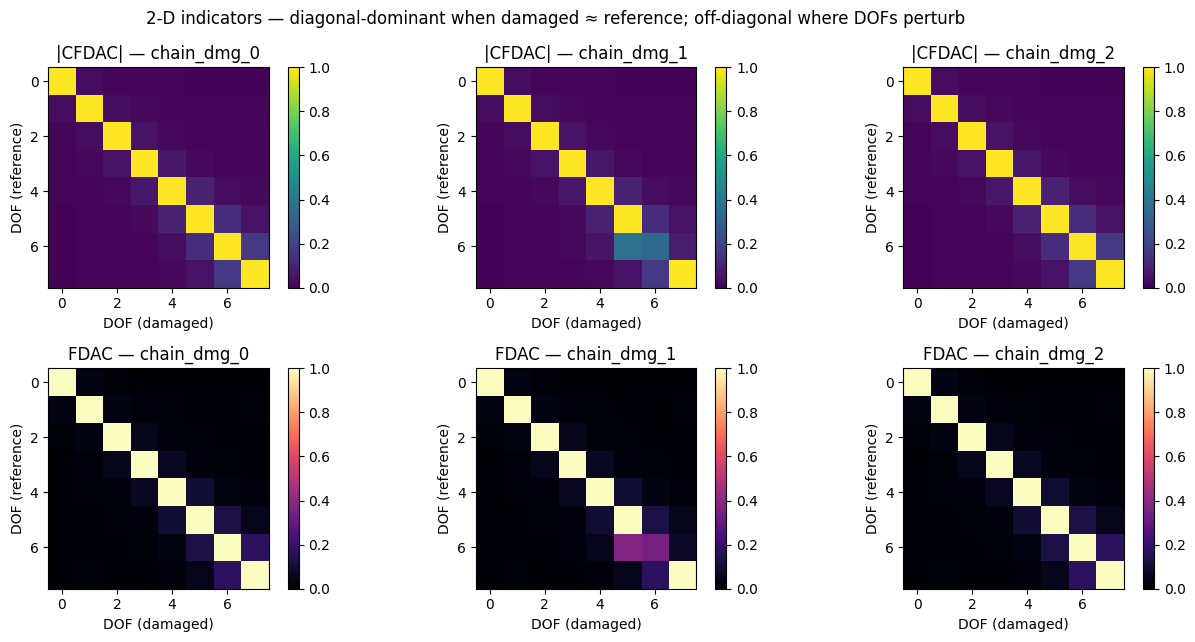

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for col, name in enumerate(dmg_chain.name):
    cf_mat = np.abs(cfdac.measurements[col][()][:, :, 0, 0])
    fd_mat =        fdac .measurements[col][()][:, :, 0, 0]
    im0 = axes[0, col].imshow(cf_mat, cmap="viridis", vmin=0, vmax=1)
    axes[0, col].set(title=f"|CFDAC| — {name}",
                     xlabel="DOF (damaged)", ylabel="DOF (reference)")
    im1 = axes[1, col].imshow(fd_mat, cmap="magma",   vmin=0, vmax=1)
    axes[1, col].set(title=f"FDAC — {name}",
                     xlabel="DOF (damaged)", ylabel="DOF (reference)")
    fig.colorbar(im0, ax=axes[0, col], fraction=0.046)
    fig.colorbar(im1, ax=axes[1, col], fraction=0.046)
plt.suptitle("2-D indicators — diagonal-dominant when damaged ≈ reference; off-diagonal where DOFs perturb")
plt.tight_layout(); plt.show()

### 8b · 1-D vector indicators (RVAC, GAC) — one bar per DOF

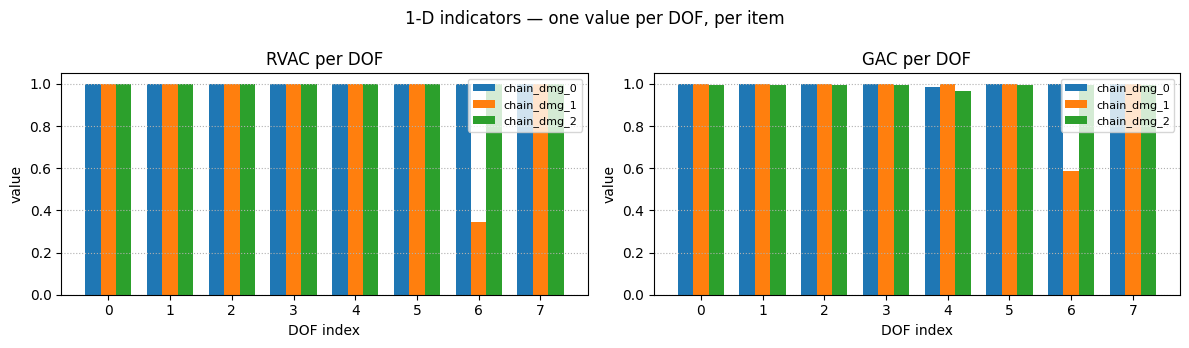

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
width = 0.25
xs = np.arange(N_DOF)
for col, (vec_coll, ax, title) in enumerate(zip(
    (rvac, gac), axes, ("RVAC per DOF", "GAC per DOF"),
)):
    for i, name in enumerate(dmg_chain.name):
        v = vec_coll.measurements[i][()][:, 0, 0]
        ax.bar(xs + (i - 1) * width, v, width=width, label=name)
    ax.set(title=title, xlabel="DOF index", ylabel="value")
    ax.set_xticks(xs); ax.legend(fontsize=8); ax.grid(True, linestyle=":", axis="y")
plt.suptitle("1-D indicators — one value per DOF, per item")
plt.tight_layout(); plt.show()

### 8c · 0-D scalar indicators — one number per item

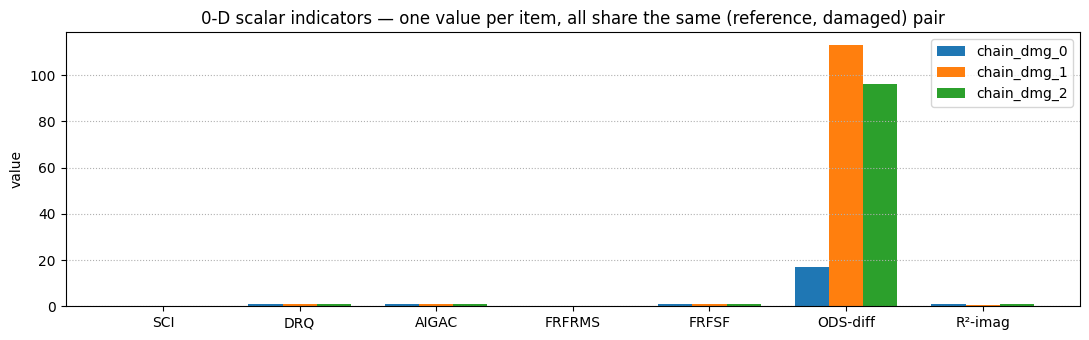

In [14]:
zero_d = {
    "SCI":      sci,
    "DRQ":      drq,
    "AIGAC":    aigac,
    "FRFRMS":   frfrms,
    "FRFSF":    frfsf,
    "ODS-diff": ods,
    "R²-imag":  r2,
}

fig, ax = plt.subplots(figsize=(11, 3.5))
labels = list(zero_d.keys())
xs = np.arange(len(labels))
width = 0.25
for i, name in enumerate(dmg_chain.name):
    vals = [coll.measurements[i][()][0, 0] for coll in zero_d.values()]
    ax.bar(xs + (i - 1) * width, vals, width=width, label=name)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set(title="0-D scalar indicators — one value per item, all share the same (reference, damaged) pair",
       ylabel="value")
ax.legend(); ax.grid(True, linestyle=":", axis="y")
plt.tight_layout(); plt.show()

## 9 · Provenance round-trip

Every indicator embeds its `reference` and `damaged` source FRFs. We can
reach back through any indicator collection to inspect the exact pair that
produced each item.

reference (item 0): shape=(51, 8, 1)  matches source? True
damaged   (item 0): shape=(51, 8, 1)  matches source? True


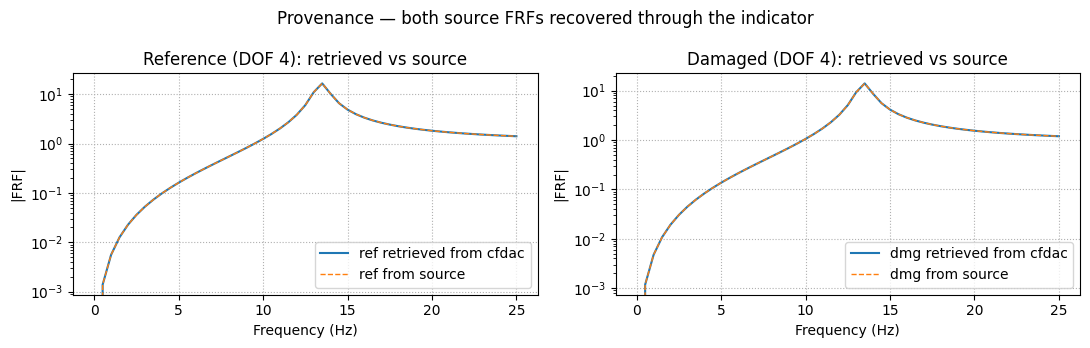

In [15]:
ref_back = cfdac.get_reference_data("reference", 0)
dmg_back = cfdac.get_reference_data("damaged",   0)
print(f"reference (item 0): shape={ref_back.shape}  matches source? "
      f"{np.allclose(ref_back, ref_chain.measurements[0][()])}")
print(f"damaged   (item 0): shape={dmg_back.shape}  matches source? "
      f"{np.allclose(dmg_back, dmg_chain.measurements[0][()])}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
freq_axis = ref_chain.freq_array          # original frequency axis of the source FRFs
axes[0].semilogy(freq_axis, np.abs(ref_back[:, 4, 0]),
                 "tab:blue",   lw=1.5, label="ref retrieved from cfdac")
axes[0].semilogy(freq_axis, np.abs(ref_chain.measurements[0][()][:, 4, 0]),
                 "tab:orange", lw=1.0, linestyle="--", label="ref from source")
axes[0].set(title="Reference (DOF 4): retrieved vs source",
            xlabel="Frequency (Hz)", ylabel="|FRF|")
axes[0].legend(); axes[0].grid(True, linestyle=":")
axes[1].semilogy(freq_axis, np.abs(dmg_back[:, 4, 0]),
                 "tab:blue",   lw=1.5, label="dmg retrieved from cfdac")
axes[1].semilogy(freq_axis, np.abs(dmg_chain.measurements[0][()][:, 4, 0]),
                 "tab:orange", lw=1.0, linestyle="--", label="dmg from source")
axes[1].set(title="Damaged (DOF 4): retrieved vs source",
            xlabel="Frequency (Hz)", ylabel="|FRF|")
axes[1].legend(); axes[1].grid(True, linestyle=":")
plt.suptitle("Provenance — both source FRFs recovered through the indicator")
plt.tight_layout(); plt.show()

## 10 · PyTorch handoff across all dimensionalities

`HDF5Dataset` reads `/measurements/{name}/data` directly, skipping the
`_axes` collection-metadata group. Item rank is whatever the writer used —
0-D collections yield rank-2 items, 1-D yield rank-3, 2-D yield rank-4 — so
a `DataLoader` over a `cfdac_collection` produces 4-D tensors out of the box.

frf (1-D)     batch x.shape=(2, 51, 8, 1)  y=[1, 0]
cfdac (2-D)   batch x.shape=(2, 8, 8, 1, 1)  y=[1, 2]
sci (0-D)     batch x.shape=(2, 1, 1)  y=[1, 2]


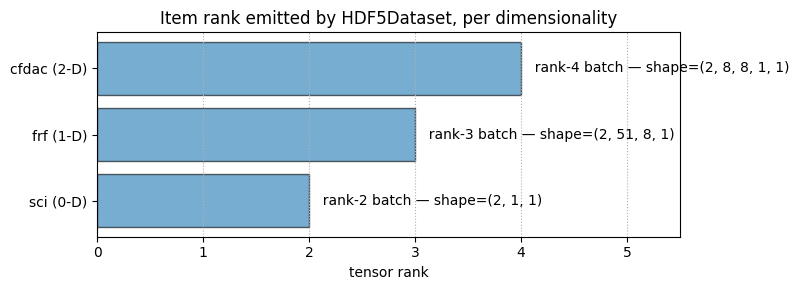

In [16]:
import torch
from torch.utils.data import DataLoader

# Round-trip through HDF5Dataset for each dimensionality we have
many.torch_dataset();   ds_1d = many.dataset
cfdac.torch_dataset();  ds_2d = cfdac.dataset
sci.torch_dataset();    ds_0d = sci.dataset

batches = {}
for name, ds in [("frf (1-D)", ds_1d), ("cfdac (2-D)", ds_2d), ("sci (0-D)", ds_0d)]:
    xb, yb = next(iter(DataLoader(ds, batch_size=2)))
    batches[name] = tuple(xb.shape)
    print(f"{name:12s}  batch x.shape={tuple(xb.shape)}  y={yb.tolist()}")

# Visualise the rank that each parent produces
fig, ax = plt.subplots(figsize=(8, 3))
ranks = {"sci (0-D)": 2, "frf (1-D)": 3, "cfdac (2-D)": 4}
for i, (name, rank) in enumerate(ranks.items()):
    ax.barh(i, rank, color="tab:blue", alpha=0.6, edgecolor="black")
    ax.text(rank + 0.05, i, f"  rank-{rank} batch — shape={batches[name]}", va="center")
ax.set_yticks(range(len(ranks))); ax.set_yticklabels(ranks.keys())
ax.set(title="Item rank emitted by HDF5Dataset, per dimensionality",
       xlabel="tensor rank", xlim=(0, 5.5))
ax.grid(True, linestyle=":", axis="x")
plt.tight_layout(); plt.show()

## 11 · Cleanup

In [17]:
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print("Removed working directory.")

Removed working directory.
